# EDS 232 Assignment 2, Task 1: Potential Problems in Linear Regression

This notebook examines three common problems that can arise when fitting a linear regression model: nonlinearity, outliers, and collinearity. For each problem we generate synthetic data, produce visualizations that make the issue visible, and discuss how to detect and address it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

plt.rcParams['figure.dpi'] = 100


---
## Issue 1: Nonlinearity

### Explanation

Linear regression assumes the relationship between the predictors and the response is linear. When this assumption does not hold the model systematically overpredicts in some regions and underpredicts in others, leaving patterns in the residuals that would not appear under a correctly specified model. This matters because it leads to biased coefficient estimates and unreliable predictions throughout the range of the data. The standard detection method is to examine the residual plot, where residuals are plotted against the fitted values: in a correctly specified model residuals should scatter randomly around zero with no discernible trend, while a curved or wavelike pattern is a clear signal that the linear form is inadequate. Nonlinearity can be addressed by applying a transformation to the predictor or the response, such as a log or square root, or by adding polynomial terms to the model.

### Question and Investigation

**Q:** The textbook recommends residual plots to detect nonlinearity, but I wanted to know whether there is a formal statistical test for this rather than relying on visual judgment alone.

**A:** Yes. The Ramsey RESET test (Regression Equation Specification Error Test) formally tests for functional form misspecification by checking whether adding powers of the fitted values to the model produces a statistically significant improvement. In Python it can be run using statsmodels: `sm.stats.diagnostic.linear_reset(model, power=2, use_f=True)`. A small p value indicates the linear form is inadequate. This complements visual inspection and is especially useful when patterns in the residual plot are subtle or the sample is small.


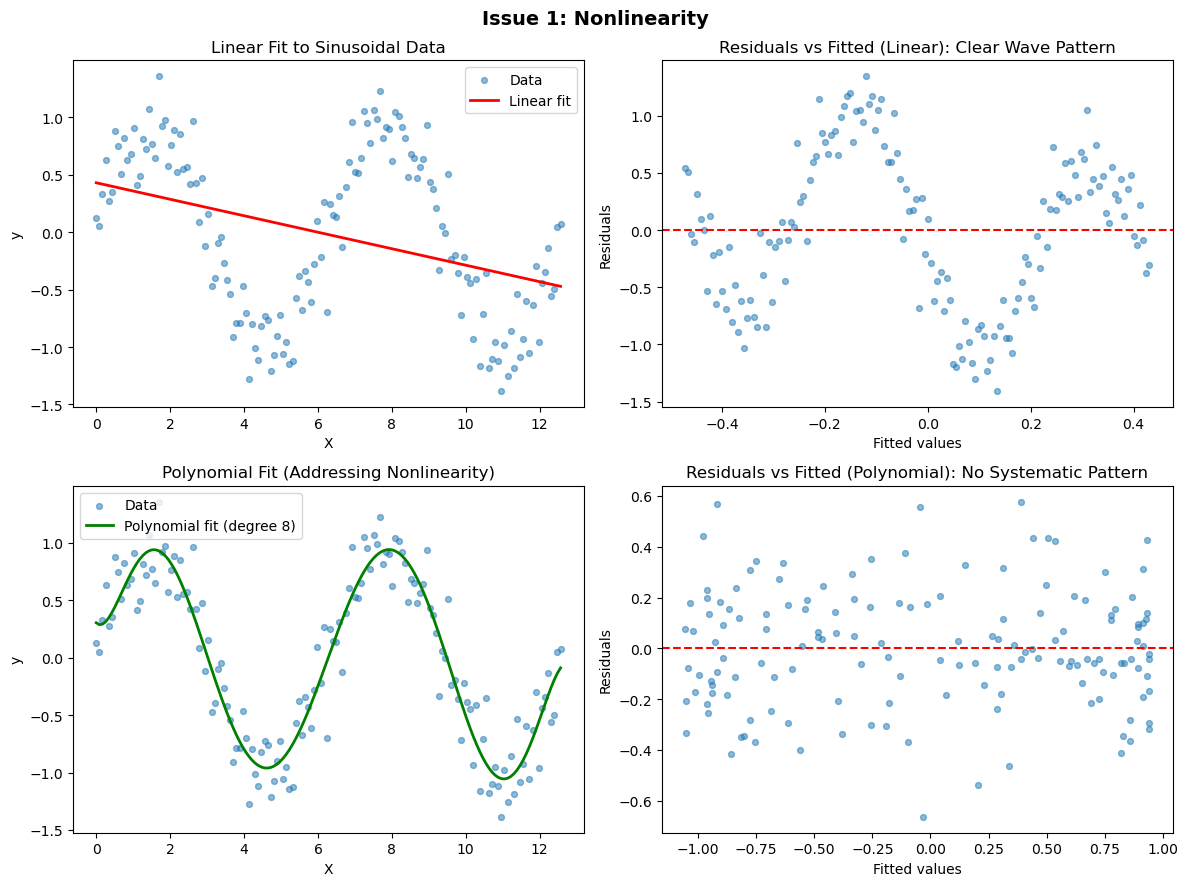

In [2]:
np.random.seed(42)
n = 150
X = np.linspace(0, 4 * np.pi, n)
y = np.sin(X) + np.random.normal(0, 0.25, n)

X_2d = X.reshape(-1, 1)

# Fit a plain linear model
linear_model = LinearRegression().fit(X_2d, y)
y_linear = linear_model.predict(X_2d)
residuals_linear = y - y_linear

# Fit a degree 8 polynomial to address nonlinearity
poly_model = make_pipeline(PolynomialFeatures(8), LinearRegression())
poly_model.fit(X_2d, y)
y_poly = poly_model.predict(X_2d)
residuals_poly = y - y_poly

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Issue 1: Nonlinearity', fontsize=14, fontweight='bold')

axes[0, 0].scatter(X, y, alpha=0.5, s=18, label='Data')
axes[0, 0].plot(X, y_linear, color='red', lw=2, label='Linear fit')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('Linear Fit to Sinusoidal Data')
axes[0, 0].legend()

axes[0, 1].scatter(y_linear, residuals_linear, alpha=0.5, s=18)
axes[0, 1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0, 1].set_xlabel('Fitted values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Fitted (Linear): Clear Wave Pattern')

axes[1, 0].scatter(X, y, alpha=0.5, s=18, label='Data')
axes[1, 0].plot(X, y_poly, color='green', lw=2, label='Polynomial fit (degree 8)')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('Polynomial Fit (Addressing Nonlinearity)')
axes[1, 0].legend()

axes[1, 1].scatter(y_poly, residuals_poly, alpha=0.5, s=18)
axes[1, 1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1, 1].set_xlabel('Fitted values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Fitted (Polynomial): No Systematic Pattern')

plt.tight_layout()
plt.show()


**Figure caption:** The top left panel shows a linear model fitted to data generated from a sinusoidal function: the flat line clearly misses the oscillating structure in the data. The top right residual plot confirms this with a pronounced wavelike pattern around zero. After fitting a degree 8 polynomial (bottom row) the residuals scatter randomly with no systematic structure, showing the nonlinearity has been resolved.


---
## Issue 2: Outliers

### Explanation

An outlier is an observation whose response value is unusual relative to what the model predicts given its predictor values. Outliers matter because they inflate the residual standard error, reduce R squared, and can pull the regression line toward them in ways that harm predictions for the rest of the data. The standard detection tool is the studentized residual, which divides each observation's residual by an estimate of its standard deviation that accounts for the observation's leverage in the model. Observations with a studentized residual greater than 3 in absolute value are conventionally flagged as potential outliers. If an outlier results from a data recording error it should be corrected or removed; if it is a genuine observation it may indicate that an important predictor is missing from the model.

### Question and Investigation

**Q:** The textbook flags observations with a studentized residual greater than 3 in absolute value as potential outliers. I wanted to understand where that specific threshold comes from rather than just accepting it as a rule.

**A:** The threshold is rooted in the normal distribution: roughly 99.7 percent of observations fall within three standard deviations of the mean under normality, so a studentized residual beyond this range is unlikely to arise by chance in a correctly specified model. This reasoning weakens as sample size grows because with many observations you would expect at least one point to exceed the threshold purely by chance even with no true outliers present. For large samples a Bonferroni corrected threshold is more appropriate, using the t distribution critical value at significance level alpha divided by n. Whether to use 2, 3, or 4 in practice depends on sample size and on how costly false positives are relative to false negatives in the application.


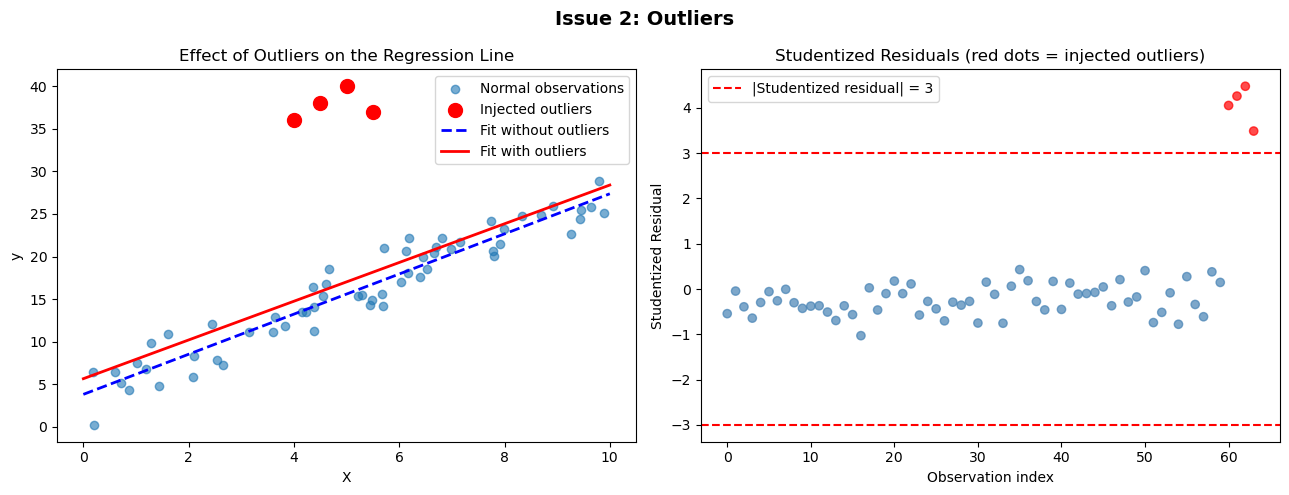

In [3]:
np.random.seed(0)
n_clean = 60
X = np.random.uniform(0, 10, n_clean)
y = 2.5 * X + 3 + np.random.normal(0, 2, n_clean)

# Inject 4 outliers with anomalously high Y values near X = 5
X_all = np.append(X, [4.0, 4.5, 5.0, 5.5])
y_all = np.append(y, [36, 38, 40, 37])
n_all = len(X_all)

# Fit models with and without outliers using statsmodels
model_clean = sm.OLS(y,     sm.add_constant(X)).fit()
model_all   = sm.OLS(y_all, sm.add_constant(X_all)).fit()

# Compute studentized residuals using the built in influence measures
influence     = model_all.get_influence()
student_resid = influence.resid_studentized_external

outlier_mask = np.zeros(n_all, dtype=bool)
outlier_mask[n_clean:] = True

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Issue 2: Outliers', fontsize=14, fontweight='bold')

X_line    = np.linspace(0, 10, 200)
X_line_sm = sm.add_constant(X_line)

axes[0].scatter(X, y, alpha=0.6, label='Normal observations')
axes[0].scatter(X_all[outlier_mask], y_all[outlier_mask],
                color='red', s=100, zorder=5, label='Injected outliers')
axes[0].plot(X_line, model_clean.predict(X_line_sm), 'b--', lw=2, label='Fit without outliers')
axes[0].plot(X_line, model_all.predict(X_line_sm),   'r-',  lw=2, label='Fit with outliers')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Effect of Outliers on the Regression Line')
axes[0].legend()

point_colors = ['red' if outlier_mask[i] else 'steelblue' for i in range(n_all)]
axes[1].scatter(range(n_all), student_resid, c=point_colors, alpha=0.7)
axes[1].axhline( 3, color='red', linestyle='--', lw=1.5, label='|Studentized residual| = 3')
axes[1].axhline(-3, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Observation index')
axes[1].set_ylabel('Studentized Residual')
axes[1].set_title('Studentized Residuals (red dots = injected outliers)')
axes[1].legend()

plt.tight_layout()
plt.show()


**Figure caption:** The left panel shows how four injected outliers (red points) pull the fitted line away from the true relationship estimated on the clean data, inflating predictions near X equal to 5. The right panel plots the studentized residual for each observation: all four injected outliers (red dots) clearly exceed the detection threshold of 3 in absolute value, while the clean observations remain well within the expected range.


---
## Issue 3: Collinearity

### Explanation

Collinearity occurs when two or more predictor variables are highly correlated with each other. In this situation the model cannot cleanly separate their individual contributions to the response because many different combinations of coefficients fit the data nearly equally well, making the estimates unstable and sensitive to small changes in the data. The practical consequence is inflated standard errors for the affected predictors, which produces wider confidence intervals and less reliable t statistics, increasing the risk of failing to detect genuinely important predictors. The standard diagnostic is the Variance Inflation Factor (VIF), defined as 1 divided by the quantity 1 minus the R squared obtained from regressing that predictor on all others: a VIF of 1 indicates no collinearity while values above 5 or 10 are generally considered problematic. The issue can be addressed by dropping one of the collinear predictors or by combining them into a single composite variable.

### Question and Investigation

**Q:** The textbook cites VIF thresholds of 5 or 10 as guidelines for identifying problematic collinearity. I wanted to understand where those specific values come from rather than treating them as arbitrary cutoffs.

**A:** The thresholds of 5 and 10 are rules of thumb rather than values with a formal statistical derivation. VIF has a direct interpretation: a VIF of k means the standard error of that coefficient is the square root of k times larger than it would be if the predictor were uncorrelated with all others. A VIF of 10 therefore corresponds to a standard error roughly 3.16 times as large, which substantially undermines the reliability of individual significance tests. Some sources use a threshold of 4, where the standard error is doubled. The right cutoff depends on context: work requiring precise individual coefficient estimates may treat even VIF above 3 as concerning, while purely predictive work that does not require interpreting individual coefficients can often tolerate higher values.


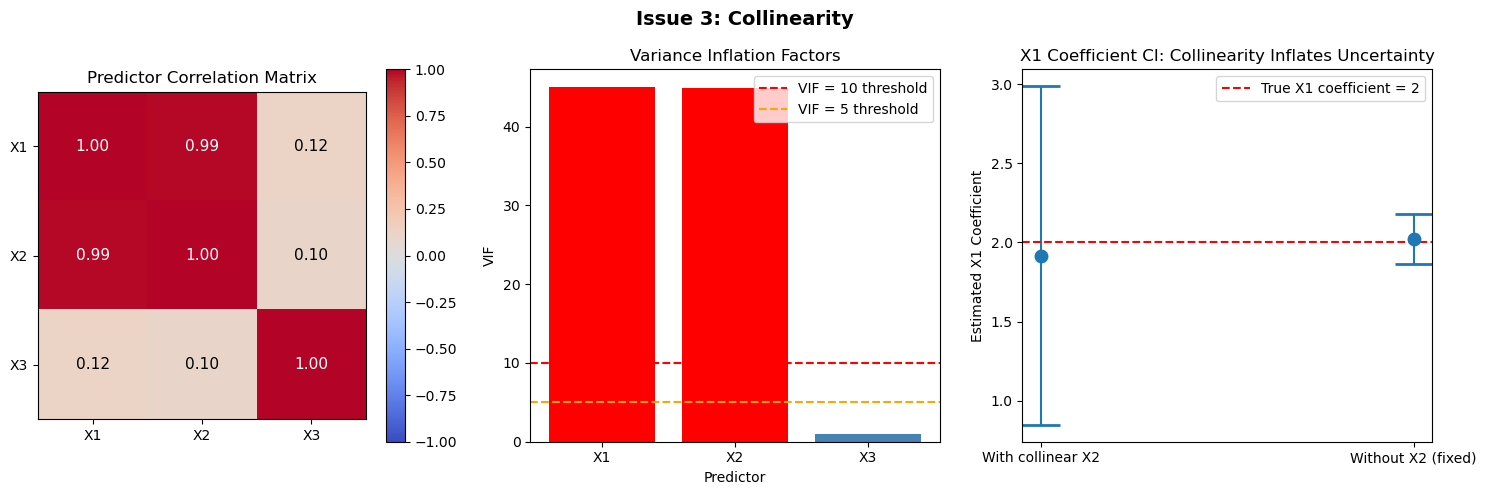

In [4]:
np.random.seed(7)
n = 150

X1 = np.random.normal(0, 1, n)
X2 = 0.97 * X1 + np.random.normal(0, 0.15, n)  # highly collinear with X1
X3 = np.random.normal(0, 1, n)                   # independent predictor

y = 2.0 * X1 + 3.0 * X3 + np.random.normal(0, 1, n)

df_col   = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3})
df_clean = pd.DataFrame({'X1': X1, 'X3': X3})

X_col_sm   = sm.add_constant(df_col)
X_clean_sm = sm.add_constant(df_clean)

model_col   = sm.OLS(y, X_col_sm).fit()
model_clean = sm.OLS(y, X_clean_sm).fit()

# VIF for each predictor (index 0 in X_col_sm is the constant, so skip it)
vif_vals  = [variance_inflation_factor(X_col_sm.values, i + 1) for i in range(3)]
vif_names = df_col.columns.tolist()

# 95% confidence intervals for the X1 coefficient in each model
ci_col   = model_col.conf_int().loc['X1']
ci_clean = model_clean.conf_int().loc['X1']
coef_col   = model_col.params['X1']
coef_clean = model_clean.params['X1']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Issue 3: Collinearity', fontsize=14, fontweight='bold')

# Panel 1: predictor correlation heatmap
corr = df_col.corr()
im = axes[0].imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(corr.columns)
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(corr.index)
for i in range(3):
    for j in range(3):
        text_color = 'white' if abs(corr.iloc[i, j]) > 0.6 else 'black'
        axes[0].text(j, i, f'{corr.iloc[i, j]:.2f}',
                     ha='center', va='center', fontsize=11, color=text_color)
axes[0].set_title('Predictor Correlation Matrix')

# Panel 2: VIF bar chart
bar_colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_vals]
axes[1].bar(vif_names, vif_vals, color=bar_colors)
axes[1].axhline(10, color='red',    linestyle='--', lw=1.5, label='VIF = 10 threshold')
axes[1].axhline(5,  color='orange', linestyle='--', lw=1.5, label='VIF = 5 threshold')
axes[1].set_xlabel('Predictor')
axes[1].set_ylabel('VIF')
axes[1].set_title('Variance Inflation Factors')
axes[1].legend()

# Panel 3: compare X1 coefficient confidence interval with and without collinear X2
labels    = ['With collinear X2', 'Without X2 (fixed)']
coefs     = [coef_col, coef_clean]
lower_err = [coef_col - ci_col[0],     coef_clean - ci_clean[0]]
upper_err = [ci_col[1] - coef_col,     ci_clean[1] - coef_clean]

axes[2].errorbar(labels, coefs, yerr=[lower_err, upper_err],
                 fmt='o', capsize=14, capthick=2, markersize=9)
axes[2].axhline(2.0, color='red', linestyle='--', lw=1.5, label='True X1 coefficient = 2')
axes[2].set_ylabel('Estimated X1 Coefficient')
axes[2].set_title('X1 Coefficient CI: Collinearity Inflates Uncertainty')
axes[2].legend()

plt.tight_layout()
plt.show()


**Figure caption:** The left panel shows the predictor correlation matrix: X1 and X2 are nearly perfectly correlated at approximately 0.98 while X3 is independent of both. The center panel confirms that X1 and X2 have VIF values far above both the 5 and 10 thresholds while X3 stays near 1. The right panel shows the practical consequence: including the collinear X2 substantially widens the confidence interval for the X1 coefficient, making it much harder to establish X1's effect even though the true coefficient is 2.


---
## Generative AI Reflection

I used Claude Code to generate the Python code for all three sections in this notebook. My prompts described each problem and specified the type of data and plots I needed, for example: generate Python code using numpy, matplotlib, and statsmodels that illustrates nonlinearity in linear regression with a sinusoidal data generating process, producing a residuals versus fitted plot showing the wavelike pattern and a second plot demonstrating that a polynomial fit resolves it. The nonlinearity and outlier sections each took about two iterations, mostly to refine axis labels and figure sizing. The collinearity section needed more revision because the first draft used sklearn's LinearRegression, which does not expose confidence intervals, so I asked Claude to rewrite it using statsmodels; a follow up iteration was still needed because that draft had a sign error in the error bar calculation that I caught by comparing the plot against the printed model summary. The outlier section's first draft computed studentized residuals by constructing the hat matrix manually, which raised a shape mismatch error I identified from the traceback and resolved by asking Claude to use statsmodels' built in get_influence method instead. Overall the AI produced useful starting code quickly, but reviewing each output carefully and debugging small errors was a necessary part of the process.
